In [44]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os


In [45]:
# Image dimensions and batch size
img_height, img_width = 224, 224  # MobileNetV2 expects 224x224 images
batch_size = 32
channels=3
train_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory='C:/Users/rajan/Music/2025/naviket/split/own_aug/train',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode='categorical'
)
val_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory='C:/Users/rajan/Music/2025/naviket/split/own_aug/val',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode='categorical'
)
test_ds=tf.keras.preprocessing.image_dataset_from_directory(
    directory='C:/Users/rajan/Music/2025/naviket/split/own_aug/test',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    label_mode='categorical'
)

# Ensure the test dataset is loaded for confusion matrix 
test_ds1 = tf.keras.preprocessing.image_dataset_from_directory(
    directory='C:/Users/rajan/Music/2025/naviket/split/own_aug/test',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False  # Do not shuffle to align predictions with labels
)

Found 4520 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Found 800 files belonging to 4 classes.
Found 800 files belonging to 4 classes.


In [46]:
num_classes=4
#enhancing pipeling
train_ds=train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [47]:
# Load EfficientNetB0 with pre-trained weights, exclude the top layers
base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the base model
base_model.trainable = False

# Add custom layers on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(num_classes, activation='softmax')(x)

# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [48]:
# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

In [49]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [50]:
# Define EarlyStopping
early_stopping = EarlyStopping(
    monitor='val_loss',      # Metric to monitor
    patience=10,             # Number of epochs to wait for improvement before stopping
    verbose=1,               # Verbosity mode
    mode='min',              # Mode to determine improvement
    restore_best_weights=True  # Restore the best weights after stopping
)


In [51]:
history = model.fit(train_ds, validation_data=val_ds, epochs=50,callbacks=[early_stopping])


Epoch 1/50
142/142 [==============================] - 26s 82ms/step - loss: 0.4694 - accuracy: 0.8569 - val_loss: 0.2112 - val_accuracy: 0.9450
Epoch 2/50
142/142 [==============================] - 8s 59ms/step - loss: 0.1697 - accuracy: 0.9544 - val_loss: 0.1293 - val_accuracy: 0.9650
Epoch 3/50
142/142 [==============================] - 8s 56ms/step - loss: 0.1179 - accuracy: 0.9666 - val_loss: 0.1060 - val_accuracy: 0.9694
Epoch 4/50
142/142 [==============================] - 8s 56ms/step - loss: 0.0892 - accuracy: 0.9777 - val_loss: 0.1043 - val_accuracy: 0.9638
Epoch 5/50
142/142 [==============================] - 8s 57ms/step - loss: 0.0751 - accuracy: 0.9810 - val_loss: 0.0737 - val_accuracy: 0.9800
Epoch 6/50
142/142 [==============================] - 8s 56ms/step - loss: 0.0666 - accuracy: 0.9832 - val_loss: 0.0946 - val_accuracy: 0.9650
Epoch 7/50
142/142 [==============================] - 8s 57ms/step - loss: 0.0570 - accuracy: 0.9838 - val_loss: 0.0632 - val_accuracy: 0.978

In [65]:
# Evaluate the model on the test set
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test accuracy: {test_acc}')

# Save the model
model.save('efficientnet.h5')

25/25 [==============================] - 2s 50ms/step - loss: 0.0674 - accuracy: 0.9775
Test accuracy: 0.9775000214576721


TypeError: Unable to serialize [2.0896919 2.1128857 2.1081853] to JSON. Unrecognized type <class 'tensorflow.python.framework.ops.EagerTensor'>.

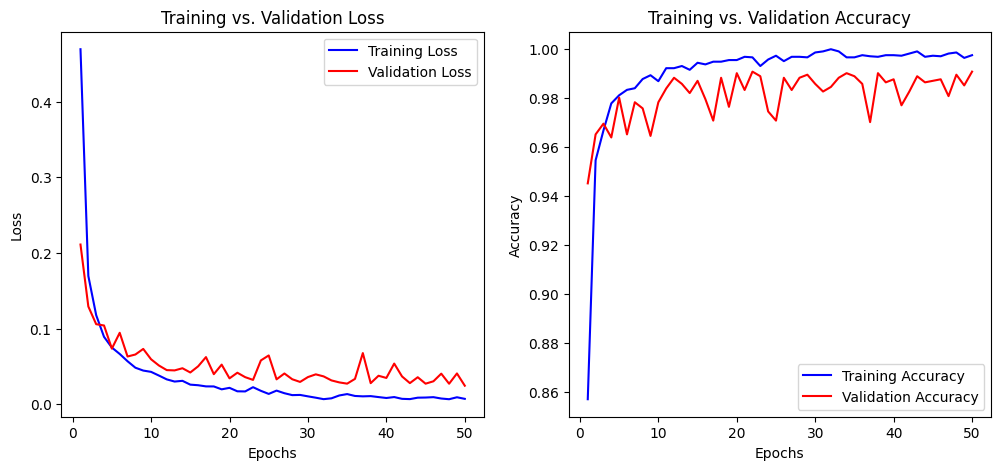

In [59]:
import matplotlib.pyplot as plt

# Extract loss and accuracy from history
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs_range = range(1, len(train_loss) + 1)

# Plot Loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, label='Training Loss', color='blue')
plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs. Validation Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, label='Training Accuracy', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs. Validation Accuracy')
plt.legend()
plt.savefig('efftraining_plot.png')
plt.show()


In [60]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels
true_labels = np.concatenate([y for x, y in test_ds1])

# Predict on test dataset
predictions = model.predict(test_ds1)
predicted_labels = np.argmax(predictions, axis=1)


25/25 [==============================] - 1s 56ms/step


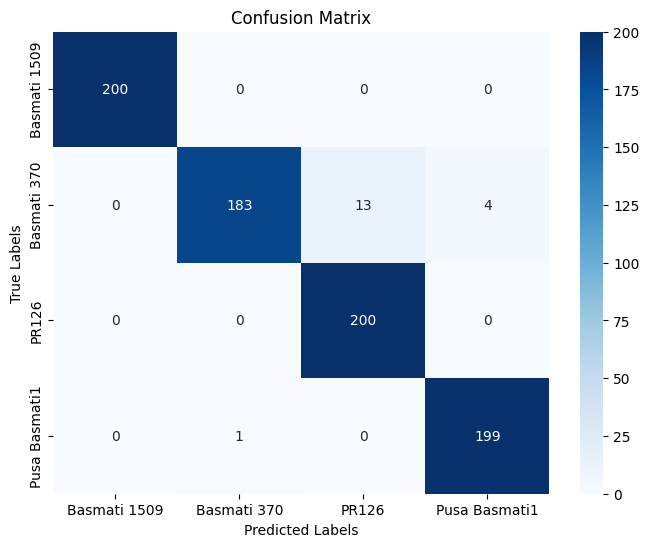

In [61]:
#!pip install seaborn
# Compute confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=test_ds1.class_names, yticklabels=test_ds1.class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.savefig('eff_cm.png')
plt.show()


In [56]:
# Generate classification report
class_report = classification_report(true_labels, predicted_labels, target_names=test_ds1.class_names)

print("Classification Report:")
print(class_report)


Classification Report:
               precision    recall  f1-score   support

 Basmati 1509       1.00      1.00      1.00       200
  Basmati 370       0.99      0.92      0.95       200
        PR126       0.94      1.00      0.97       200
Pusa Basmati1       0.98      0.99      0.99       200

     accuracy                           0.98       800
    macro avg       0.98      0.98      0.98       800
 weighted avg       0.98      0.98      0.98       800



In [64]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Generate classification report as a string
class_report = classification_report(true_labels, predicted_labels, target_names=test_ds1.class_names)

# Print the report to console
print("Classification Report:")
print(class_report)

# Create a figure and render the text
plt.figure(figsize=(10, 6))
plt.text(0.01, 0.05, class_report, {'fontsize': 10}, fontproperties='monospace')  # Use monospace for alignment
plt.axis('off')  # Turn off the axes

# Save the text as an image
plt.savefig('effclassification_report.png', bbox_inches='tight')
plt.close()


Classification Report:
               precision    recall  f1-score   support

 Basmati 1509       1.00      1.00      1.00       200
  Basmati 370       0.99      0.92      0.95       200
        PR126       0.94      1.00      0.97       200
Pusa Basmati1       0.98      0.99      0.99       200

     accuracy                           0.98       800
    macro avg       0.98      0.98      0.98       800
 weighted avg       0.98      0.98      0.98       800



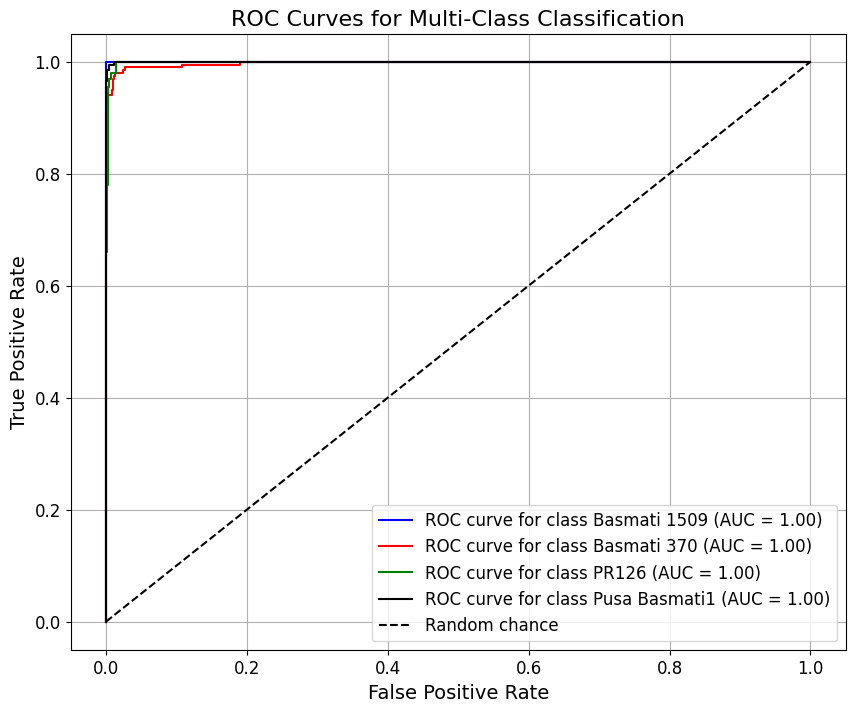

In [62]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Step 1: Convert true labels to one-hot
num_classes = len(test_ds1.class_names)
true_labels_onehot = label_binarize(true_labels, classes=range(num_classes))

# Step 2: Get predictions (already done earlier)
# predictions = model.predict(test_ds1)

# Step 3: Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(true_labels_onehot[:, i], predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Step 4: Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green','black']  # Adjust based on number of classes

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i],
             label=f'ROC curve for class {test_ds1.class_names[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random chance')

# Font size customization
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curves for Multi-Class Classification', fontsize=16)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True)
plt.savefig('eff_roc.png')
plt.show()
